# 05 - GAF Image-Based Anomaly Detection (Branch C)

**Li-ion Battery Degradation Anomaly Detection Using Deep Learning**

---

## Branch C Strategy

Convert capacity curves into Gramian Angular Field (GAF) images and apply image-based anomaly detection:

1. **PatchCore** - pretrained ResNet feature extraction with a coreset memory bank (effective with little training data)
2. **CNN-AE** - convolutional autoencoder for GAF image reconstruction

### Key Advantage over Branch B
- Branch B captures fine-grained patterns inside sliding windows
- Branch C captures the **shape of the entire capacity curve** as an image, enabling global pattern comparison
- Progressive GAF enables early detection by generating GAFs at cycle cutoffs `[20, 30, 50, 75, 100, 150, 200]`

### Available Data (from `02_feature_engineering`)
- `gaf_images_full.pkl`: 35 cells x (3, 64, 64) - full-curve GAFs
- `gaf_images_progressive.pkl`: 35 cells x 7 cutoffs x (3, 64, 64) - for early detection


## 0. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import pickle
import os
import time
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc
from scipy.spatial.distance import cdist

PROJECT_DIR = '/content/drive/MyDrive/battery-anomaly-detection'
PROCESSED_DIR = os.path.join(PROJECT_DIR, 'processed_data')
RESULTS_DIR = os.path.join(PROJECT_DIR, 'results')
MODEL_DIR = os.path.join(PROJECT_DIR, 'models')
for d in [RESULTS_DIR, MODEL_DIR]:
 os.makedirs(d, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print('Setup complete.')

Mounted at /content/drive
Device: cuda
Setup complete.


---
## 1. Load GAF Images

In [2]:
# Full-curve GAF images
with open(os.path.join(PROCESSED_DIR, 'gaf_images_full.pkl'), 'rb') as f:
 gaf_data = pickle.load(f)

gaf_images = gaf_data['images'] # {cell_id: (3, 64, 64)}
gaf_labels = gaf_data['labels'] # {cell_id: {'dataset': ..., 'group': ...}}
GAF_SIZE = gaf_data['image_size'] # 64

# Progressive GAF images
with open(os.path.join(PROCESSED_DIR, 'gaf_images_progressive.pkl'), 'rb') as f:
 progressive_gaf = pickle.load(f)

# Ground truth & Diao baselines
gt_d1 = pd.read_csv(os.path.join(PROCESSED_DIR, 'ground_truth_d1.csv'))
diao_baselines = pd.read_csv(os.path.join(PROCESSED_DIR, 'diao2020_baselines.csv'), index_col=0)

# Auto-detect progressive cutoffs from saved data
PROGRESSIVE_CYCLES = sorted(list(list(progressive_gaf.values())[0].keys()))

print(f'Full GAF: {len(gaf_images)} images, shape={list(gaf_images.values())[0].shape}')
print(f'Progressive GAF: {len(progressive_gaf)} cells')
print(f' Cutoffs: {PROGRESSIVE_CYCLES}')

# Organize by dataset and group
data_info = {}
for cell_id, label in gaf_labels.items():
 ds = label['dataset']
 grp = label['group']
 if ds not in data_info:
 data_info[ds] = {'Qualified': [], 'Subsequent': []}
 data_info[ds][grp].append(cell_id)

for ds in ['Dataset1', 'Dataset2']:
 nq = len(data_info[ds]['Qualified'])
 ns = len(data_info[ds]['Subsequent'])
 print(f'{ds}: {nq} qualified, {ns} subsequent')

print(f'\nDiao 2020 mean: {diao_baselines.values.mean():.1f}')

Full GAF: 35 images, shape=(3, 64, 64)
Progressive GAF: 35 cells
  Cutoffs: [20, 30, 40, 50, 60, 75, 100, 125, 150, 175, 200]
Dataset1: 6 qualified, 6 subsequent
Dataset2: 14 qualified, 9 subsequent

Diao 2020 mean: 179.6


---
## 2. PatchCore - Feature Extraction

PatchCore principle: extract intermediate-layer features from a pretrained ResNet, build a memory bank from normal images, then use the distance between a test image's features and the memory bank as the anomaly score.

GAF images are 64x64 with 3 channels, so they are resized to 224x224 for the ResNet18 input.


In [3]:
class PatchCoreDetector:
 def __init__(self, backbone='resnet18', layer_indices=[1, 2], k_ratio=0.1):
 """
 PatchCore-style anomaly detector for GAF images.

 Args:
 backbone: pretrained model name
 layer_indices: which ResNet layer blocks to extract features from
 k_ratio: coreset sampling ratio (0.1 = keep 10% of patches)
 """
 self.device = device
 self.k_ratio = k_ratio

 # Load pretrained ResNet
 if backbone == 'resnet18':
 model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
 else:
 model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

 model.eval()
 self.model = model.to(device)

 # Hook intermediate layers
 self.features = {}
 self.layer_indices = layer_indices

 def get_hook(name):
 def hook(module, input, output):
 self.features[name] = output.detach()
 return hook

 layers = [model.layer1, model.layer2, model.layer3, model.layer4]
 for idx in layer_indices:
 layers[idx].register_forward_hook(get_hook(f'layer{idx+1}'))

 # Image preprocessing (ImageNet normalization)
 self.transform = transforms.Compose([
 transforms.Normalize(mean=[0.485, 0.456, 0.406],
 std=[0.229, 0.224, 0.225])
 ])

 self.memory_bank = None

 def _extract_features(self, images):
 """Extract and concatenate multi-scale patch features."""
 # images: (N, 3, 64, 64) numpy -> resize to 224×224
 imgs_tensor = torch.FloatTensor(images).to(self.device)

 # Resize to 224×224
 imgs_resized = F.interpolate(imgs_tensor, size=(224, 224), mode='bilinear', align_corners=False)

 # Normalize per-channel to ImageNet range
 # GAF values are in [-1, 1], shift to [0, 1] first
 imgs_norm = (imgs_resized - imgs_resized.min()) / (imgs_resized.max() - imgs_resized.min() + 1e-8)
 imgs_norm = self.transform(imgs_norm)

 # Forward pass
 self.features = {}
 with torch.no_grad():
 _ = self.model(imgs_norm)

 # Concatenate features from selected layers
 all_features = []
 target_size = None
 for idx in self.layer_indices:
 feat = self.features[f'layer{idx+1}'] # (N, C, H, W)
 if target_size is None:
 target_size = feat.shape[2:]
 else:
 feat = F.interpolate(feat, size=target_size, mode='bilinear', align_corners=False)
 all_features.append(feat)

 # Concatenate along channel dim: (N, C_total, H, W)
 concat = torch.cat(all_features, dim=1)

 # Reshape to patches: (N, C, H, W) -> (N*H*W, C)
 N, C, H, W = concat.shape
 patches = concat.permute(0, 2, 3, 1).reshape(N * H * W, C)

 return patches.cpu().numpy(), (N, H, W, C)

 def fit(self, normal_images):
 """Build memory bank from normal (Qualified) images."""
 print(f' Extracting features from {len(normal_images)} normal images...')
 patches, shape_info = self._extract_features(normal_images)
 N, H, W, C = shape_info
 print(f' Patch features: {patches.shape} (N*H*W, C)')

 # Coreset subsampling (greedy farthest point)
 n_keep = max(1, int(len(patches) * self.k_ratio))
 print(f' Coreset sampling: {len(patches)} -> {n_keep} patches...')

 # Simple random sampling for efficiency (full greedy is slow)
 np.random.seed(42)
 indices = np.random.choice(len(patches), n_keep, replace=False)
 self.memory_bank = patches[indices]

 print(f' Memory bank: {self.memory_bank.shape}')
 return self

 def score(self, images):
 """Compute anomaly scores for test images."""
 patches, shape_info = self._extract_features(images)
 N, H, W, C = shape_info

 # Compute distance to nearest neighbor in memory bank
 # Process in chunks to avoid memory issues
 chunk_size = H * W # one image at a time
 scores = []

 for i in range(N):
 start = i * chunk_size
 end = start + chunk_size
 img_patches = patches[start:end] # (H*W, C)

 # Distance to nearest memory bank patch
 dists = cdist(img_patches, self.memory_bank, metric='euclidean')
 min_dists = dists.min(axis=1) # (H*W,)

 # Image score = max patch distance (the most anomalous patch)
 scores.append(float(min_dists.max()))

 return np.array(scores)

print('PatchCore detector defined.')

PatchCore detector defined.


---
## 3. PatchCore - Full Curve Evaluation

Cell-level anomaly detection on the GAF of the full capacity curve.
Fit on qualified cells only, then score every cell.


In [4]:
patchcore_results = {}

for ds in ['Dataset1', 'Dataset2']:
 print(f'\n{"="*50}')
 print(f'PatchCore — {ds}')
 print(f'{"="*50}')

 # Prepare images
 qual_ids = data_info[ds]['Qualified']
 subseq_ids = data_info[ds]['Subsequent']

 qual_imgs = np.stack([gaf_images[cid] for cid in qual_ids]) # (N_q, 3, 64, 64)
 subseq_imgs = np.stack([gaf_images[cid] for cid in subseq_ids]) # (N_s, 3, 64, 64)
 all_imgs = np.concatenate([qual_imgs, subseq_imgs])
 all_ids = qual_ids + subseq_ids

 print(f' Qualified: {qual_imgs.shape}, Subsequent: {subseq_imgs.shape}')

 # Fit on qualified
 detector = PatchCoreDetector(layer_indices=[1, 2], k_ratio=0.25)
 detector.fit(qual_imgs)

 # Score all
 all_scores = detector.score(all_imgs)

 # Store results
 results = {}
 for i, cid in enumerate(all_ids):
 grp = gaf_labels[cid]['group']
 results[cid] = {
 'score': all_scores[i],
 'group': grp,
 }

 patchcore_results[ds] = results

 # Print scores
 print(f'\n Scores:')
 for cid in sorted(results.keys()):
 r = results[cid]
 marker = ' ' if r['group'] == 'Qualified' else '**'
 print(f' {marker}{cid}: {r["score"]:.4f} ({r["group"]})')

print('\n PatchCore full-curve evaluation complete.')


PatchCore — Dataset1
  Qualified: (6, 3, 64, 64), Subsequent: (6, 3, 64, 64)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 211MB/s]


  Extracting features from 6 normal images...
  Patch features: (4704, 384) (N*H*W, C)
  Coreset sampling: 4704 → 1176 patches...
  Memory bank: (1176, 384)

  Scores:
      D1_Qual_1: 4.4044 (Qualified)
      D1_Qual_2: 4.5386 (Qualified)
      D1_Qual_3: 4.4866 (Qualified)
      D1_Qual_4: 4.4884 (Qualified)
      D1_Qual_5: 4.5375 (Qualified)
      D1_Qual_6: 4.4844 (Qualified)
    **D1_Subseq_1: 4.5843 (Subsequent)
    **D1_Subseq_2: 4.6647 (Subsequent)
    **D1_Subseq_3: 4.6584 (Subsequent)
    **D1_Subseq_4: 4.6858 (Subsequent)
    **D1_Subseq_5: 4.4758 (Subsequent)
    **D1_Subseq_6: 4.5207 (Subsequent)

PatchCore — Dataset2
  Qualified: (14, 3, 64, 64), Subsequent: (9, 3, 64, 64)
  Extracting features from 14 normal images...
  Patch features: (10976, 384) (N*H*W, C)
  Coreset sampling: 10976 → 2744 patches...
  Memory bank: (2744, 384)

  Scores:
      D2_Qual_1: 2.8025 (Qualified)
      D2_Qual_10: 2.6956 (Qualified)
      D2_Qual_11: 2.7362 (Qualified)
      D2_Qual_12: 2.76

---
## 4. PatchCore — Cell-Level AUC

In [5]:
def compute_patchcore_auc(results_dict):
 rows = []
 for ds in ['Dataset1', 'Dataset2']:
 results = results_dict[ds]
 labels = [1 if r['group']=='Subsequent' else 0 for r in results.values()]
 scores = [r['score'] for r in results.values()]

 if len(set(labels)) < 2:
 continue

 roc = roc_auc_score(labels, scores)
 prec, rec, _ = precision_recall_curve(labels, scores)
 pr = auc(rec, prec)

 rows.append({
 'dataset': ds, 'method': 'PatchCore',
 'ROC_AUC': roc, 'PR_AUC': pr,
 'n_normal': labels.count(0), 'n_anomaly': labels.count(1),
 })
 return pd.DataFrame(rows)

pc_auc = compute_patchcore_auc(patchcore_results)
print('=== PatchCore Cell-Level AUC ===')
display(pc_auc)

=== PatchCore Cell-Level AUC ===


,dataset,method,ROC_AUC,PR_AUC,n_normal,n_anomaly
0,Dataset1,PatchCore,0.805556,0.868867,6,6
1,Dataset2,PatchCore,0.896825,0.799707,14,9


---
## 5. PatchCore - Progressive Early Detection

At each cycle cutoff, generate a GAF and compute the anomaly score.
The first cutoff at which the score exceeds the threshold is the detection cycle.


In [6]:
# PROGRESSIVE_CYCLES is loaded from Cell 4 automatically
print(f'Using cutoffs: {PROGRESSIVE_CYCLES}')

prog_results = {}

for ds in ['Dataset1', 'Dataset2']:
 print(f'\n{"="*50}')
 print(f'Progressive PatchCore — {ds}')
 print(f'{"="*50}')

 qual_ids = data_info[ds]['Qualified']
 subseq_ids = data_info[ds]['Subsequent']

 # --- Build memory bank from qualified FULL curves ---
 qual_full = np.stack([gaf_images[cid] for cid in qual_ids])
 detector = PatchCoreDetector(layer_indices=[1, 2], k_ratio=0.25)
 detector.fit(qual_full)

 # --- Also build memory banks from qualified progressive images ---
 # For each cutoff, create qualified reference
 prog_detectors = {}
 for n_cyc in PROGRESSIVE_CYCLES:
 qual_prog = []
 for cid in qual_ids:
 if cid in progressive_gaf and n_cyc in progressive_gaf[cid]:
 qual_prog.append(progressive_gaf[cid][n_cyc])
 if len(qual_prog) >= 2:
 qual_prog = np.stack(qual_prog)
 det = PatchCoreDetector(layer_indices=[1, 2], k_ratio=0.25)
 print(f' Building detector for cutoff={n_cyc} ({len(qual_prog)} qualified images)')
 det.fit(qual_prog)
 prog_detectors[n_cyc] = det

 # --- Score subsequent cells at each cutoff ---
 prog_results[ds] = {}
 all_cell_ids = qual_ids + subseq_ids

 for cid in all_cell_ids:
 grp = gaf_labels[cid]['group']
 scores_by_cycle = {}

 for n_cyc in PROGRESSIVE_CYCLES:
 if cid in progressive_gaf and n_cyc in progressive_gaf[cid]:
 img = progressive_gaf[cid][n_cyc] # (3, 64, 64)
 if n_cyc in prog_detectors:
 score = prog_detectors[n_cyc].score(img[np.newaxis])[0]
 scores_by_cycle[n_cyc] = score

 prog_results[ds][cid] = {
 'group': grp,
 'scores': scores_by_cycle,
 }

print('\n Progressive PatchCore complete.')

Using cutoffs: [20, 30, 40, 50, 60, 75, 100, 125, 150, 175, 200]

Progressive PatchCore — Dataset1
  Extracting features from 6 normal images...
  Patch features: (4704, 384) (N*H*W, C)
  Coreset sampling: 4704 → 1176 patches...
  Memory bank: (1176, 384)
  Building detector for cutoff=20 (6 qualified images)
  Extracting features from 6 normal images...
  Patch features: (4704, 384) (N*H*W, C)
  Coreset sampling: 4704 → 1176 patches...
  Memory bank: (1176, 384)
  Building detector for cutoff=30 (6 qualified images)
  Extracting features from 6 normal images...
  Patch features: (4704, 384) (N*H*W, C)
  Coreset sampling: 4704 → 1176 patches...
  Memory bank: (1176, 384)
  Building detector for cutoff=40 (6 qualified images)
  Extracting features from 6 normal images...
  Patch features: (4704, 384) (N*H*W, C)
  Coreset sampling: 4704 → 1176 patches...
  Memory bank: (1176, 384)
  Building detector for cutoff=50 (6 qualified images)
  Extracting features from 6 normal images...
  Patch

---
## 6. Progressive Detection Cycle Estimation

In [7]:
def estimate_progressive_detection(prog_results, n_ds='Dataset1'):
    results = prog_results[n_ds]

    # Burn-in: skip early SEI-formation cycles in Dataset 2
    BURN_IN = 30 if 'Dataset2' in n_ds else 0

    # Compute threshold from qualified scores at each cutoff (skip burn-in)
    qual_thresholds = {}
    for n_cyc in PROGRESSIVE_CYCLES:
        if n_cyc <= BURN_IN:
            continue
        qual_scores = []
        for cid, r in results.items():
            if r['group'] == 'Qualified' and n_cyc in r['scores']:
                qual_scores.append(r['scores'][n_cyc])
        if len(qual_scores) >= 2:
            qual_scores = np.array(qual_scores)
            qual_thresholds[n_cyc] = {
                'mean+3σ': np.mean(qual_scores) + 3 * np.std(qual_scores),
                'mean+2σ': np.mean(qual_scores) + 2 * np.std(qual_scores),
                'P95': np.percentile(qual_scores, 95),
            }

    # Detection: first cutoff where score > threshold (after burn-in)
    det_rows = []
    for cid, r in results.items():
        for thr_name in ['mean+3σ', 'mean+2σ', 'P95']:
            det_cycle = None
            for n_cyc in PROGRESSIVE_CYCLES:
                if n_cyc <= BURN_IN:
                    continue
                if n_cyc in r['scores'] and n_cyc in qual_thresholds:
                    if r['scores'][n_cyc] > qual_thresholds[n_cyc][thr_name]:
                        det_cycle = n_cyc
                        break
            det_rows.append({
                'dataset': n_ds, 'cell_id': cid,
                'group': r['group'], 'method': 'PatchCore_Prog',
                'threshold_type': thr_name,
                'detection_cycle': det_cycle,
            })

    return pd.DataFrame(det_rows), qual_thresholds

# Run for both datasets
all_prog_det = []
for ds in ['Dataset1', 'Dataset2']:
    det_df, thresholds = estimate_progressive_detection(prog_results, ds)
    all_prog_det.append(det_df)

    burn_in = 30 if 'Dataset2' in ds else 0
    print(f'\n=== {ds} Progressive Detection (burn-in={burn_in}) ===')
    for thr in ['mean+3σ', 'mean+2σ', 'P95']:
        sub = det_df[
            (det_df['group']=='Subsequent') &
            (det_df['threshold_type']==thr) &
            (det_df['detection_cycle'].notna())
        ]
        fp = det_df[
            (det_df['group']=='Qualified') &
            (det_df['threshold_type']==thr) &
            (det_df['detection_cycle'].notna())
        ]
        n_total = len(det_df[(det_df['group']=='Subsequent')&(det_df['threshold_type']==thr)])
        if len(sub) > 0:
            print(f'  {thr}: detected {len(sub)}/{n_total}, '
                  f'mean={sub["detection_cycle"].mean():.1f}, FP={len(fp)}')
            for _, row in sub.iterrows():
                print(f'    {row["cell_id"]}: cycle {int(row["detection_cycle"])}')

prog_det_df = pd.concat(all_prog_det, ignore_index=True)

print(f'\nDiao 2020 mean: {diao_baselines.values.mean():.1f}')


=== Dataset1 Progressive Detection (burn-in=0) ===
  mean+3σ: detected 2/6, mean=110.0, FP=0
    D1_Subseq_3: cycle 20
    D1_Subseq_4: cycle 200
  mean+2σ: detected 6/6, mean=50.0, FP=1
    D1_Subseq_1: cycle 20
    D1_Subseq_2: cycle 20
    D1_Subseq_3: cycle 20
    D1_Subseq_4: cycle 200
    D1_Subseq_5: cycle 20
    D1_Subseq_6: cycle 20
  P95: detected 6/6, mean=50.0, FP=1
    D1_Subseq_1: cycle 20
    D1_Subseq_2: cycle 20
    D1_Subseq_3: cycle 20
    D1_Subseq_4: cycle 200
    D1_Subseq_5: cycle 20
    D1_Subseq_6: cycle 20

=== Dataset2 Progressive Detection (burn-in=30) ===
  mean+3σ: detected 2/9, mean=67.5, FP=0
    D2_Subseq_18: cycle 60
    D2_Subseq_20: cycle 75
  mean+2σ: detected 7/9, mean=64.3, FP=2
    D2_Subseq_15: cycle 75
    D2_Subseq_16: cycle 75
    D2_Subseq_18: cycle 60
    D2_Subseq_19: cycle 60
    D2_Subseq_20: cycle 60
    D2_Subseq_21: cycle 60
    D2_Subseq_23: cycle 60
  P95: detected 9/9, mean=46.1, FP=8
    D2_Subseq_15: cycle 40
    D2_Subseq_16: c

---
## 7. Score Trajectory Visualization

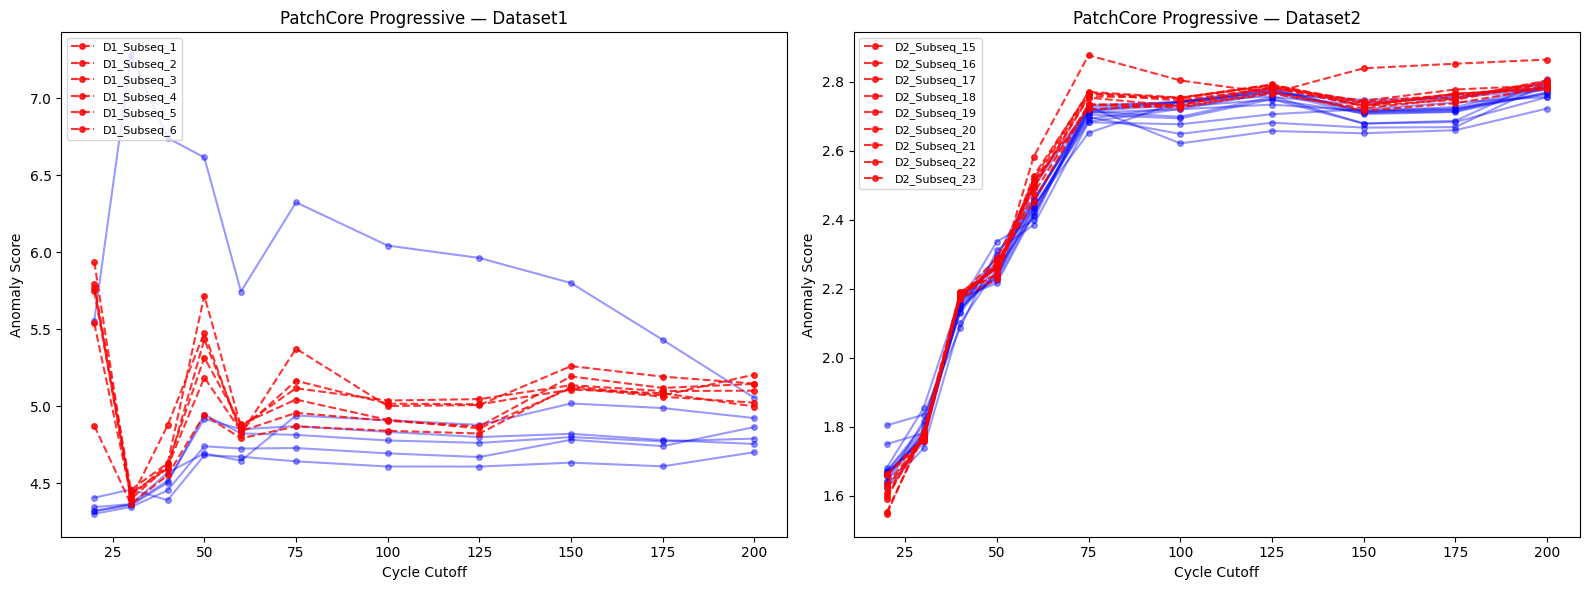

✓ Saved: /content/drive/MyDrive/battery-anomaly-detection/results/fig_patchcore_progressive.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, ds in enumerate(['Dataset1', 'Dataset2']):
 ax = axes[idx]
 results = prog_results[ds]

 for cid, r in sorted(results.items()):
 if not r['scores']:
 continue
 cycles = sorted(r['scores'].keys())
 scores = [r['scores'][c] for c in cycles]

 c = 'blue' if r['group'] == 'Qualified' else 'red'
 ls = '-' if r['group'] == 'Qualified' else '--'
 a = 0.4 if r['group'] == 'Qualified' else 0.8
 lbl = cid if r['group'] == 'Subsequent' else None
 ax.plot(cycles, scores, color=c, ls=ls, alpha=a, lw=1.5, marker='o', markersize=4, label=lbl)

 ax.set_title(f'PatchCore Progressive — {ds}')
 ax.set_xlabel('Cycle Cutoff')
 ax.set_ylabel('Anomaly Score')
 ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
save_path = os.path.join(RESULTS_DIR, 'fig_patchcore_progressive.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f' Saved: {save_path}')

---
## 8. CNN Autoencoder — GAF Reconstruction

In [9]:
class CNNAE(nn.Module):
 def __init__(self, in_channels=3, latent_dim=32):
 super().__init__()

 # Encoder: (3, 64, 64) -> latent
 self.encoder = nn.Sequential(
 nn.Conv2d(in_channels, 16, 3, stride=2, padding=1), # -> (16, 32, 32)
 nn.BatchNorm2d(16), nn.ReLU(),
 nn.Conv2d(16, 32, 3, stride=2, padding=1), # -> (32, 16, 16)
 nn.BatchNorm2d(32), nn.ReLU(),
 nn.Conv2d(32, 64, 3, stride=2, padding=1), # -> (64, 8, 8)
 nn.BatchNorm2d(64), nn.ReLU(),
 nn.Conv2d(64, 128, 3, stride=2, padding=1), # -> (128, 4, 4)
 nn.BatchNorm2d(128), nn.ReLU(),
 )
 self.enc_fc = nn.Linear(128 * 4 * 4, latent_dim)

 # Decoder: latent -> (3, 64, 64)
 self.dec_fc = nn.Linear(latent_dim, 128 * 4 * 4)
 self.decoder = nn.Sequential(
 nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1), # -> (64, 8, 8)
 nn.BatchNorm2d(64), nn.ReLU(),
 nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), # -> (32, 16, 16)
 nn.BatchNorm2d(32), nn.ReLU(),
 nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1), # -> (16, 32, 32)
 nn.BatchNorm2d(16), nn.ReLU(),
 nn.ConvTranspose2d(16, in_channels, 4, stride=2, padding=1), # -> (3, 64, 64)
 nn.Tanh(),
 )

 def forward(self, x):
 # Encode
 h = self.encoder(x)
 h = h.view(h.size(0), -1)
 z = self.enc_fc(h)
 # Decode
 h = self.dec_fc(z)
 h = h.view(h.size(0), 128, 4, 4)
 return self.decoder(h)

_t = CNNAE().to(device)
_o = _t(torch.randn(2, 3, 64, 64).to(device))
print(f'CNN-AE defined. Shape: (2,3,64,64) -> {tuple(_o.shape)}')
print(f'Params: {sum(p.numel() for p in _t.parameters()):,}')
del _t, _o

CNN-AE defined. Shape: (2,3,64,64) → (2, 3, 64, 64)
Params: 404,211


---
## 9. CNN-AE Training - Progressive Images

Train on progressive GAFs: use every cutoff image of qualified cells as training data.
This lets the model learn normal GAF patterns at multiple time points.


In [10]:
import torch.optim as optim

def train_cnnae(dataset_name, epochs=200, lr=1e-3, patience=20):
 qual_ids = data_info[dataset_name]['Qualified']

 # Collect all progressive images from qualified cells
 # Filter to only include images with correct shape (3, 64, 64)
 train_imgs = []
 target_shape = (3, GAF_SIZE, GAF_SIZE)

 for cid in qual_ids:
 if cid in progressive_gaf:
 for n_cyc, img in progressive_gaf[cid].items():
 if img.shape == target_shape:
 train_imgs.append(img)
 # Also add full curve image
 if gaf_images[cid].shape == target_shape:
 train_imgs.append(gaf_images[cid])

 print(f'{dataset_name}: collected {len(train_imgs)} images with shape {target_shape}')
 train_imgs = np.stack(train_imgs) # (N, 3, 64, 64)

 # Normalize to [-1, 1] (for Tanh output)
 img_min = train_imgs.min()
 img_max = train_imgs.max()
 train_imgs = 2 * (train_imgs - img_min) / (img_max - img_min + 1e-8) - 1

 # Train/val split
 np.random.seed(42)
 n = len(train_imgs)
 idx = np.random.permutation(n)
 val_size = max(2, int(n * 0.2))
 X_train = torch.FloatTensor(train_imgs[idx[val_size:]])
 X_val = torch.FloatTensor(train_imgs[idx[:val_size]])

 train_loader = DataLoader(TensorDataset(X_train), batch_size=16, shuffle=True)
 val_loader = DataLoader(TensorDataset(X_val), batch_size=16, shuffle=False)

 print(f' train={len(X_train)}, val={len(X_val)}, range=[{img_min:.3f}, {img_max:.3f}]')

 # Train
 model = CNNAE(latent_dim=32).to(device)
 optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
 scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=30, T_mult=2, eta_min=1e-6)
 criterion = nn.MSELoss()

 best_val = float('inf')
 patience_cnt = 0
 best_state = None
 start = time.time()

 for epoch in range(epochs):
 model.train()
 t_losses = []
 for (batch,) in train_loader:
 batch = batch.to(device)
 optimizer.zero_grad()
 out = model(batch)
 loss = criterion(out, batch)
 loss.backward()
 optimizer.step()
 t_losses.append(loss.item())

 model.eval()
 v_losses = []
 with torch.no_grad():
 for (batch,) in val_loader:
 batch = batch.to(device)
 out = model(batch)
 v_losses.append(criterion(out, batch).item())

 t_loss = np.mean(t_losses)
 v_loss = np.mean(v_losses)
 scheduler.step()

 if v_loss < best_val:
 best_val = v_loss
 patience_cnt = 0
 best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
 else:
 patience_cnt += 1

 if (epoch+1) % 30 == 0 or epoch == 0:
 print(f' Epoch {epoch+1:3d}/{epochs} | Train: {t_loss:.6f} | Val: {v_loss:.6f} | Best: {best_val:.6f}')

 if patience_cnt >= patience:
 print(f' Early stopping at epoch {epoch+1}')
 break

 model.load_state_dict(best_state)
 model = model.to(device)
 print(f' CNN-AE/{dataset_name} | Best: {best_val:.6f} | {time.time()-start:.1f}s')

 return model, (img_min, img_max)

cnnae_models = {}
cnnae_norms = {}
for ds in ['Dataset1', 'Dataset2']:
 print(f'\n{"="*50}')
 model, norms = train_cnnae(ds)
 cnnae_models[ds] = model
 cnnae_norms[ds] = norms


Dataset1: collected 42 images with shape (3, 64, 64)
  train=34, val=8, range=[-1.000, 1.000]
  Epoch   1/200 | Train: 0.544509 | Val: 0.351329 | Best: 0.351329
  Epoch  30/200 | Train: 0.051781 | Val: 0.050057 | Best: 0.050057
  Epoch  60/200 | Train: 0.015310 | Val: 0.015499 | Best: 0.015499
  Epoch  90/200 | Train: 0.013318 | Val: 0.012834 | Best: 0.012828
  Epoch 120/200 | Train: 0.010620 | Val: 0.009015 | Best: 0.009015
  Epoch 150/200 | Train: 0.006252 | Val: 0.006760 | Best: 0.006760
  Epoch 180/200 | Train: 0.005482 | Val: 0.005997 | Best: 0.005997
  ✓ CNN-AE/Dataset1 | Best: 0.005860 | 3.8s

Dataset2: collected 98 images with shape (3, 64, 64)
  train=79, val=19, range=[-1.000, 1.000]
  Epoch   1/200 | Train: 0.364742 | Val: 0.299548 | Best: 0.299548
  Epoch  30/200 | Train: 0.013599 | Val: 0.013544 | Best: 0.013544
  Epoch  60/200 | Train: 0.003368 | Val: 0.003312 | Best: 0.003312
  Epoch  90/200 | Train: 0.002771 | Val: 0.002680 | Best: 0.002680
  Epoch 120/200 | Train: 0.0

---
## 10. CNN-AE — Progressive Scoring

In [11]:
def score_cnnae_progressive(model, prog_gaf, gaf_images, data_info, ds, norms):
 img_min, img_max = norms
 model.eval()

 all_ids = data_info[ds]['Qualified'] + data_info[ds]['Subsequent']
 results = {}
 target_shape = (3, GAF_SIZE, GAF_SIZE)

 for cid in all_ids:
 grp = gaf_labels[cid]['group']
 scores = {}

 for n_cyc in PROGRESSIVE_CYCLES:
 if cid in prog_gaf and n_cyc in prog_gaf[cid]:
 img = prog_gaf[cid][n_cyc]

 # Skip or resize if shape doesn't match
 if img.shape != target_shape:
 # Resize to 64x64 using interpolation
 img_t = torch.FloatTensor(img).unsqueeze(0)
 img = F.interpolate(img_t, size=(GAF_SIZE, GAF_SIZE), mode='bilinear', align_corners=False).squeeze(0).numpy()

 # Normalize same way as training
 img_norm = 2 * (img - img_min) / (img_max - img_min + 1e-8) - 1
 img_t = torch.FloatTensor(img_norm).unsqueeze(0).to(device)

 with torch.no_grad():
 out = model(img_t)
 mse = ((out - img_t) ** 2).mean().item()
 scores[n_cyc] = mse

 results[cid] = {'group': grp, 'scores': scores}

 return results

cnnae_prog_results = {}
for ds in ['Dataset1', 'Dataset2']:
 cnnae_prog_results[ds] = score_cnnae_progressive(
 cnnae_models[ds], progressive_gaf, gaf_images, data_info, ds, cnnae_norms[ds]
 )
 print(f'{ds}: {len(cnnae_prog_results[ds])} cells scored')

# Detection cycles
all_cnnae_det = []
for ds in ['Dataset1', 'Dataset2']:
 det_df, _ = estimate_progressive_detection(cnnae_prog_results, ds)
 det_df['method'] = 'CNN_AE_Prog'
 all_cnnae_det.append(det_df)

 print(f'\n=== {ds} CNN-AE Progressive Detection ===')
 for thr in ['mean+3σ', 'mean+2σ', 'P95']:
 sub = det_df[(det_df['group']=='Subsequent') & (det_df['threshold_type']==thr) & (det_df['detection_cycle'].notna())]
 fp = det_df[(det_df['group']=='Qualified') & (det_df['threshold_type']==thr) & (det_df['detection_cycle'].notna())]
 n_total = det_df[(det_df['group']=='Subsequent') & (det_df['threshold_type']==thr)].shape[0]
 if len(sub) > 0:
 print(f' {thr}: detected {len(sub)}/{n_total}, mean={sub["detection_cycle"].mean():.1f}, FP={len(fp)}')

cnnae_det_df = pd.concat(all_cnnae_det, ignore_index=True)
print(f'\nDiao 2020 mean: {diao_baselines.values.mean():.1f}')

Dataset1: 12 cells scored
Dataset2: 23 cells scored

=== Dataset1 CNN-AE Progressive Detection ===
  mean+3σ: detected 6/6, mean=75.0, FP=0
  mean+2σ: detected 6/6, mean=75.0, FP=1
  P95: detected 6/6, mean=75.0, FP=2

=== Dataset2 CNN-AE Progressive Detection ===
  mean+3σ: detected 9/9, mean=42.2, FP=0
  mean+2σ: detected 9/9, mean=41.1, FP=4
  P95: detected 9/9, mean=40.0, FP=5

Diao 2020 mean: 179.6


---
## 11. Combined Comparison — All Branches

In [12]:
# Load previous results
baseline_det = pd.read_csv(os.path.join(PROCESSED_DIR, 'baseline_detection_cycles.csv'))
dl_det = pd.read_csv(os.path.join(PROCESSED_DIR, 'dl_detection_cycles.csv'))
baseline_auc = pd.read_csv(os.path.join(PROCESSED_DIR, 'baseline_auc_metrics.csv'))
dl_auc = pd.read_csv(os.path.join(PROCESSED_DIR, 'dl_auc_metrics.csv'))

print('=' * 70)
print('COMBINED RESULTS — ALL BRANCHES')
print('=' * 70)

# --- AUC ---
print('\n=== Cell-Level AUC ===')
combined_auc = pd.concat([
 baseline_auc.assign(branch='A'),
 dl_auc.assign(branch='B (6F)'),
 pc_auc.assign(branch='C (PatchCore)'),
])
pivot = combined_auc.pivot_table(
 index=['branch', 'method'], columns='dataset',
 values=['ROC_AUC', 'PR_AUC']
).round(4)
display(pivot)

# --- Detection Cycles (D1 Subsequent) ---
print('\n=== Mean Detection Cycle — D1 Subsequent ===')
print(f' Diao 2020: {diao_baselines.values.mean():.1f}')

# Branch A - LOF
d1_lof = baseline_det[(baseline_det['dataset']=='Dataset1') & (baseline_det['group']=='Subsequent') & (baseline_det['method']=='LOF') & (baseline_det['detection_cycle'].notna())]
if len(d1_lof) > 0:
 print(f' LOF (Branch A): {d1_lof["detection_cycle"].mean():.1f}')

# Branch B - LSTM-AE best
for thr in ['P95', 'mean+3σ']:
 d1_lstm = dl_det[(dl_det['dataset']=='Dataset1') & (dl_det['group']=='Subsequent') & (dl_det['method']=='LSTM_AE') & (dl_det['threshold_type']==thr) & (dl_det['detection_cycle'].notna())]
 fp_lstm = dl_det[(dl_det['group']=='Qualified') & (dl_det['method']=='LSTM_AE') & (dl_det['threshold_type']==thr) & (dl_det['detection_cycle'].notna())]
 if len(d1_lstm) > 0:
 print(f' LSTM-AE {thr} (B): {d1_lstm["detection_cycle"].mean():.1f} (FP={len(fp_lstm)})')

# Branch C - PatchCore Progressive
for thr in ['P95', 'mean+3σ']:
 d1_pc = prog_det_df[(prog_det_df['dataset']=='Dataset1') & (prog_det_df['group']=='Subsequent') & (prog_det_df['threshold_type']==thr) & (prog_det_df['detection_cycle'].notna())]
 fp_pc = prog_det_df[(prog_det_df['group']=='Qualified') & (prog_det_df['threshold_type']==thr) & (prog_det_df['detection_cycle'].notna())]
 if len(d1_pc) > 0:
 print(f' PatchCore {thr} (C): {d1_pc["detection_cycle"].mean():.1f} (detected {len(d1_pc)}/6, FP={len(fp_pc)})')

# Branch C - CNN-AE Progressive
for thr in ['P95', 'mean+3σ']:
 d1_cnn = cnnae_det_df[(cnnae_det_df['dataset']=='Dataset1') & (cnnae_det_df['group']=='Subsequent') & (cnnae_det_df['threshold_type']==thr) & (cnnae_det_df['detection_cycle'].notna())]
 fp_cnn = cnnae_det_df[(cnnae_det_df['group']=='Qualified') & (cnnae_det_df['threshold_type']==thr) & (cnnae_det_df['detection_cycle'].notna())]
 if len(d1_cnn) > 0:
 print(f' CNN-AE {thr} (C): {d1_cnn["detection_cycle"].mean():.1f} (detected {len(d1_cnn)}/6, FP={len(fp_cnn)})')

COMBINED RESULTS — ALL BRANCHES

=== Cell-Level AUC ===


PR_AUC           ROC_AUC         
dataset                            Dataset1 Dataset2 Dataset1 Dataset2
branch        method                                                  
A             LOF                    1.0000   1.0000   1.0000   1.0000
              Mahalanobis Distance   0.7616   0.8359   0.6667   0.8254
              OC-SVM                 0.9742   0.8984   0.9722   0.9206
              SPRT                   1.0000   0.9883   1.0000   0.9921
B (6F)        LSTM_AE                1.0000   0.9710   1.0000   0.9762
              TCN_AE                 1.0000   0.8475   1.0000   0.8175
              Transformer_AE         1.0000   0.9513   1.0000   0.9603
C (PatchCore) PatchCore              0.8689   0.7997   0.8056   0.8968


=== Mean Detection Cycle — D1 Subsequent ===
  Diao 2020:              179.6
  LOF (Branch A):         143.5
  LSTM-AE P95 (B):     45.2  (FP=16)
  LSTM-AE mean+3σ (B):     100.5  (FP=11)
  PatchCore P95 (C):   50.0  (detected 6/6, FP=9)
  PatchCore mean+3σ (C):   110.0  (detected 2/6, FP=0)
  CNN-AE P95 (C):      75.0  (detected 6/6, FP=7)
  CNN-AE mean+3σ (C):      75.0  (detected 6/6, FP=0)


---
## 12. Save Results

In [13]:
# PatchCore full-curve
pc_full = pd.DataFrame([
 {'dataset': ds, 'cell_id': cid, 'group': r['group'], 'method': 'PatchCore', 'score': r['score']}
 for ds, results in patchcore_results.items()
 for cid, r in results.items()
])
pc_full.to_csv(os.path.join(PROCESSED_DIR, 'patchcore_full_scores.csv'), index=False)
print(' patchcore_full_scores.csv')

# PatchCore progressive detection
prog_det_df.to_csv(os.path.join(PROCESSED_DIR, 'patchcore_progressive_detection.csv'), index=False)
print(' patchcore_progressive_detection.csv')

# CNN-AE detection
cnnae_det_df.to_csv(os.path.join(PROCESSED_DIR, 'cnnae_progressive_detection.csv'), index=False)
print(' cnnae_progressive_detection.csv')

# PatchCore AUC
pc_auc.to_csv(os.path.join(PROCESSED_DIR, 'patchcore_auc_metrics.csv'), index=False)
print(' patchcore_auc_metrics.csv')

# Progressive scores (for ensemble)
with open(os.path.join(PROCESSED_DIR, 'branchC_progressive_scores.pkl'), 'wb') as f:
 pickle.dump({
 'patchcore': prog_results,
 'cnnae': cnnae_prog_results,
 }, f)
print(' branchC_progressive_scores.pkl')

print('\n=== 05 Branch C Complete ===')
print('Ready for: 06_ensemble_evaluation.ipynb')

✓ patchcore_full_scores.csv
✓ patchcore_progressive_detection.csv
✓ cnnae_progressive_detection.csv
✓ patchcore_auc_metrics.csv
✓ branchC_progressive_scores.pkl

=== 05 Branch C Complete ===
Ready for: 06_ensemble_evaluation.ipynb
